### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
from imblearn.over_sampling import RandomOverSampler

In [5]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras import layers

### Step 2: Load Dataset

In [6]:
red = pd.read_csv('./data/redwinequality.csv', sep=';')
white = pd.read_csv('./data/whitewinequality.csv', sep=';')

In [7]:
red['type'] = 1
white['type'] = 0

In [8]:
df = pd.concat([red, white], ignore_index=True)

In [9]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


### Step 3: Exploaring Data

Basic Info

In [10]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.246114
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [12]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

Feature Distribution Info

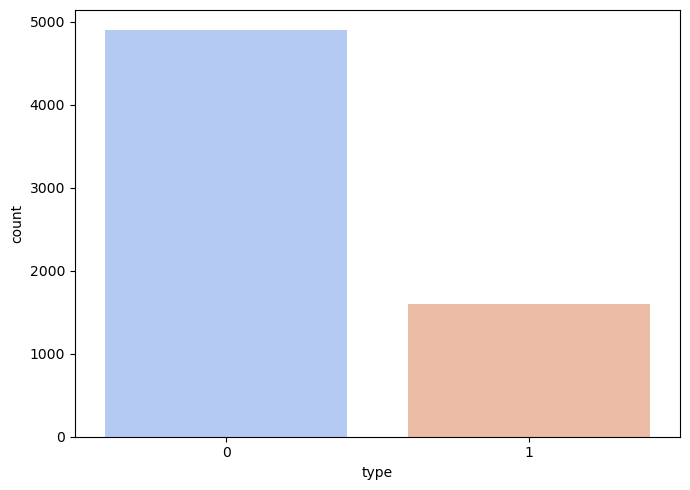

In [13]:
plt.figure(figsize=(7, 5))
sns.countplot(x='type', data=df, palette='coolwarm')
plt.tight_layout()

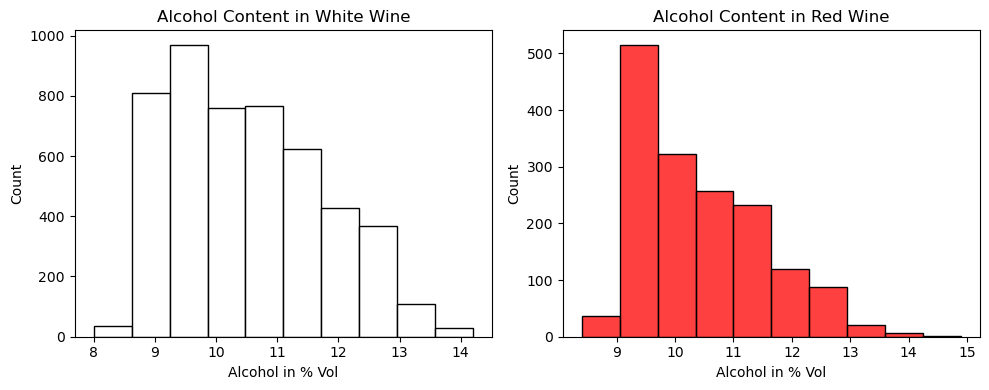

In [14]:
plt.figure(figsize=(10, 4))
for i in range(2):
    plt.subplot(1, 2, i+1)
    wine_type = 'Red' if i else 'White'
    sns.histplot(df[df['type'] == i]['alcohol'], bins=10, color=wine_type)
    plt.xlabel('Alcohol in % Vol')
    plt.title('Alcohol Content in {} Wine'.format(wine_type))
plt.tight_layout()

### Step 4: Feature Engineering

Handling Missing Values

In [15]:
df.dropna(axis=0, ignore_index=True, inplace=True)

Normalization

In [16]:
scaler = StandardScaler()

In [17]:
for col in df.columns[:-1]:
    df[col] = scaler.fit_transform(df[[col]])

<Axes: >

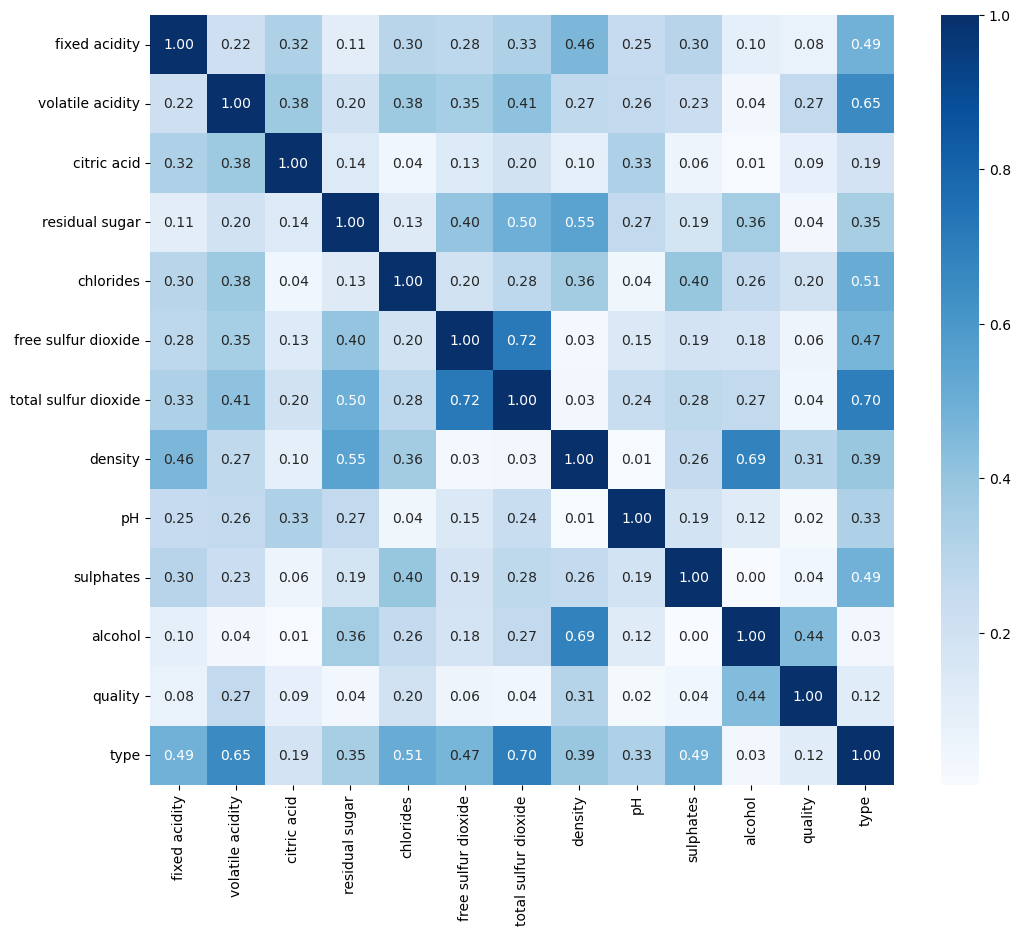

In [18]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)

### Step 5: Preparing Data

Preparing Features and Target

In [19]:
features = df.drop('type', axis=1)
target = df['type']

Balanced Data

In [20]:
ros = RandomOverSampler(random_state=42)

In [21]:
features, target = ros.fit_resample(features, target)

Split Data

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

### Step 6: Building Model

In [24]:
class FC(Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.fn1 = layers.Dense(12, activation=tf.nn.relu)
        self.fn2 = layers.Dense(9, activation=tf.nn.relu)
        self.out = layers.Dense(1, activation=tf.nn.sigmoid)
    def call(self, x):
        x = self.fn1(x)
        x = self.fn2(x)
        x = self.out(x)
        return x

In [25]:
model = FC()

In [26]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Step 7: Training Model

In [27]:
history = model.fit(X_train, y_train, epochs=3, batch_size=1, verbose=1)

Epoch 1/3
7836/7836 ━━━━━━━━━━━━━━━━━━━━ 6s 701us/step - accuracy: 0.9843 - loss: 0.0653
Epoch 2/3
7836/7836 ━━━━━━━━━━━━━━━━━━━━ 6s 722us/step - accuracy: 0.9932 - loss: 0.0313
Epoch 3/3
7836/7836 ━━━━━━━━━━━━━━━━━━━━ 6s 704us/step - accuracy: 0.9939 - loss: 0.0258


### Step 8: Evaluate Model

In [28]:
val_loss, val_acc = model.evaluate(X_test, y_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - accuracy: 0.9944 - loss: 0.0265


In [29]:
print("loss-> ", round(val_loss, 3),"\nacc-> ",round(val_acc, 3))

loss->  0.027 
acc->  0.994


### Step 9: Model Prediction

In [30]:
y_pred = model.predict(X_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [35]:
y_pred_labels = (y_pred >= 0.5).astype(int)

In [41]:
for i in range(12):
    prediction = y_pred_labels[i]
    true_label = y_test.iloc[i]
    wine_type_pred = "Red wine" if prediction == 1 else "White wine"
    wine_type = "Red wine" if true_label == 1 else "White wine"
    
    print(f"Prediction: {wine_type_pred}, True Lable: {wine_type}")

Prediction: Red wine, True Lable: Red wine
Prediction: Red wine, True Lable: Red wine
Prediction: White wine, True Lable: White wine
Prediction: Red wine, True Lable: Red wine
Prediction: Red wine, True Lable: Red wine
Prediction: Red wine, True Lable: Red wine
Prediction: Red wine, True Lable: Red wine
Prediction: Red wine, True Lable: Red wine
Prediction: White wine, True Lable: White wine
Prediction: White wine, True Lable: White wine
Prediction: White wine, True Lable: White wine
Prediction: White wine, True Lable: White wine
